Comparación de regresión lineal con y sin PCA utilizando el dataset “California
Housing”. 
Se dispone del dataset California Housing
(sklearn.datasets.fetch_california_housing), que contiene variables
predictoras sobre características de viviendas y una variable objetivo que
representa el valor medio de la vivienda. Se desea comparar el desempeño de
un modelo de regresión lineal utilizando:

Los datos originales completos (sin reducción de dimensionalidad).

1)Cargar y explorar el dataset: dimensiones, nombres de variables,
estadísticas básicas

In [11]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target #representa lo q queremos predecir con el modelo

print("Dimensiones del dataset:", X.count())
print("\nVariables predictoras:", list(X.columns))
print("\nEstadísticas básicas:\n", X.describe())


Dimensiones del dataset: MedInc        20640
HouseAge      20640
AveRooms      20640
AveBedrms     20640
Population    20640
AveOccup      20640
Latitude      20640
Longitude     20640
dtype: int64

Variables predictoras: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Estadísticas básicas:
              MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100    

La regresión lineal es un método estadístico y de machine learning que sirve para predecir un valor numérico (variable dependiente o “objetivo”) en función de una o varias variables de entrada (independientes o “predictoras”).
Básicamente, busca una línea recta (o un plano/hiperplano si hay más de 1 variable) que mejor se ajuste a los datos.



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
#(2) Divido en test y train, indico que el test tendra un 20%

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Estandarizo
#la estandarizacion de los datos 
# (3) Estandarizar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [21]:
# (4) Regresión lineal con datos originales
# Regresión lineal con datos originales
from sklearn.metrics import mean_squared_error
lr = LinearRegression()#regresion lineal
lr.fit(X_train_scaled, y_train)# regresion lineal con los datos de entrenamiento y el valor que queremos predecir
y_pred_orig = lr.predict(X_test_scaled) # obtengo las predicciones con el conjunto de datos utilizados para el test
mse_orig = mean_squared_error(y_test, y_pred_orig) #comparo los datos de el test y su prediccion
print("\n Error con datos originales:", mse_orig)



 Error con datos originales: 0.5558915986952442


In [25]:
# (5) Aplicar PCA para explicar al menos el 95% de la varianza
pca = PCA(n_components=0.95)   # conserva los componentes suficientes para ≥95%
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("\nNúmero de componentes seleccionados con PCA:", pca.n_components_)
print("Proporción de varianza explicada(el porcentaje):", np.sum(pca.explained_variance_ratio_))



Número de componentes seleccionados con PCA: 6
Proporción de varianza explicada(el porcentaje): 0.9837479817532601


In [26]:
# (6) Regresión lineal con datos proyectados (PCA)
lr_pca = LinearRegression()
lr_pca.fit(X_train_pca, y_train)
y_pred_pca = lr_pca.predict(X_test_pca)
mse_pca = mean_squared_error(y_test, y_pred_pca)
print("Error con PCA:", mse_pca)
print("Error sin PCA:", mse_orig)

Error con PCA: 0.6713632829708936
Error sin PCA: 0.5558915986952442


Podemos concluir que con PCA, si bien se tiene el 98% de la informacion de la varianza de los datos, no se tiene tanta precision de al momento de realizar un modelo, por lo que es recomendable utilizar los datos originales, es decir, que se recomienda utilizar las 8 variables, no las 6 PCA

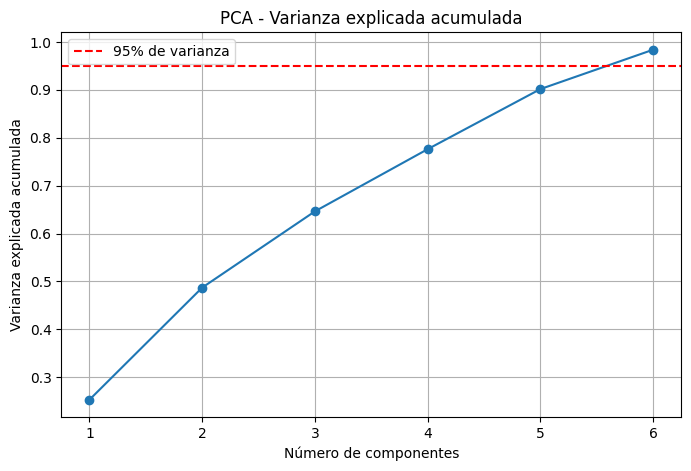

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# (8) Graficar varianza explicada acumulada
explained_var_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_var_ratio)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label="95% de varianza")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.title("PCA - Varianza explicada acumulada")
plt.legend()
plt.grid(True)
plt.show()


PCA ayuda a reducir dimensionalidad y ruido, pero no siempre mejora el rendimiento. En este caso, como solo había 8 variables y no eran demasiadas, PCA no aportó ventajas y hasta perjudicó un poco el modelo.